In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

REPORTS_DIR = r"D:\FYP\SafeRoute-AI\reports"
os.makedirs(REPORTS_DIR, exist_ok=True)

# Path to Indian MoRTH blackspot dataset
india_csv_path = r"D:\FYP\datasets\Indian\RA2021_A52.csv"

# Load with latin1 encoding to handle special characters
df_india = pd.read_csv(india_csv_path, encoding="latin1")

print(f"Dataset Shape: {df_india.shape[0]} rows × {df_india.shape[1]} columns")
print("\nColumn Names:")
for i, col in enumerate(df_india.columns, 1):
    print(f"  {i:2d}. {repr(col)}")

print("\nFirst 3 records preview:")
df_india.head(3)

Dataset Shape: 273 rows × 15 columns

Column Names:
   1. 'State'
   2. 'Name of District (Traffic unit)'
   3. 'Name of Jurisdictional Police Station'
   4. 'NH/SH/MDR/OR No.'
   5. 'Name of Location Place'
   6. 'Limits of High Accident Prone Location - Starting from (km)'
   7. 'Limits of High Accident Prone Location - Ending to (km)'
   8. 'Numbers of Accidents - 2016'
   9. 'Numbers of Accidents - 2017'
  10. 'Numbers of Accidents - 2018'
  11. 'Numbers of Accidents - Total of all three years'
  12. 'Numbers of Fatalities - 2016'
  13. 'Numbers of Fatalities - 2017'
  14. 'Numbers of Fatalities - 2018'
  15. 'Numbers of Fatalities - Total of all three years'

First 3 records preview:


,State,Name of District (Traffic unit),Name of Jurisdictional Police Station,NH/SH/MDR/OR No.,Name of Location Place,Limits of High Accident Prone Location - Starting from (km),Limits of High Accident Prone Location - Ending to (km),Numbers of Accidents - 2016,Numbers of Accidents - 2017,Numbers of Accidents - 2018,Numbers of Accidents - Total of all three years,Numbers of Fatalities - 2016,Numbers of Fatalities - 2017,Numbers of Fatalities - 2018,Numbers of Fatalities - Total of all three years
0,Tripura,West,Amtali PS,NH,Siddhi Ashram,1 mtr.,400 mtrs.,7,4.0,3.0,14,3,3.0,1.0,7
1,Tripura,SPJ,Bisramganj,NH,Chesrimai to Puskar Bari,0,1/2 KM,7,3.0,4.0,14,5,1.0,0.0,6
2,Tripura,West,Ranirbazar PS,NH,Bridhinagar,1 mtr.,425 mtrs.,6,2.0,4.0,12,2,2.0,1.0,5


In [3]:
# Strip whitespace from column names
df_india.columns = df_india.columns.str.strip()

# Clean State names (strip whitespace)
df_india['State'] = df_india['State'].astype(str).str.strip()

# Convert numeric columns to float/int (handling any string artifacts)
numeric_cols = [
    'Numbers of Accidents - 2016',
    'Numbers of Accidents - 2017',
    'Numbers of Accidents - 2018',
    'Numbers of Accidents - Total of all three years',
    'Numbers of Fatalities - 2016',
    'Numbers of Fatalities - 2017',
    'Numbers of Fatalities - 2018',
    'Numbers of Fatalities - Total of all three years'
]

for col in numeric_cols:
    df_india[col] = pd.to_numeric(df_india[col].astype(str).str.replace(',', ''), errors='coerce').fillna(0)

# Check unique states and blackspot counts
state_summary = df_india.groupby('State').agg(
    Blackspots=('Name of Location Place', 'count'),
    Total_Accidents=('Numbers of Accidents - Total of all three years', 'sum'),
    Total_Fatalities=('Numbers of Fatalities - Total of all three years', 'sum')
).sort_values(by='Blackspots', ascending=False)

# Compute Fatality Rate (Fatalities per Accident)
state_summary['Fatality_Rate_%'] = (state_summary['Total_Fatalities'] / state_summary['Total_Accidents']) * 100

print("State-wise Distribution of Blackspots:")
display(state_summary)

State-wise Distribution of Blackspots:


,Blackspots,Total_Accidents,Total_Fatalities,Fatality_Rate_%
State,,,,
Andhra Pradesh,10,327,349,106.727829
Chhattishgarh,10,128,129,100.781250
Bihar,10,155,202,130.322581
Delhi,10,427,165,38.641686
Haryana,10,213,217,101.877934
Gujarat,10,286,338,118.181818
Goa,10,91,77,84.615385
Jammu and Kashmir,10,263,178,67.680608
Jharkhand,10,67,43,64.179104


In [4]:
# 1. Standardize state spelling anomalies for GeoJSON mapping
state_name_fixes = {
    'Chhattishgarh': 'Chhattisgarh',
    'Maharastra': 'Maharashtra',
    'Uttrakhand': 'Uttarakhand',
    'Megahalaya': 'Meghalaya',
    'Orrisha': 'Odisha',
    'Orissa': 'Odisha'
}
df_india['State'] = df_india['State'].replace(state_name_fixes)

# 2. Compute Fatality Risk Index (FRI) as defined in Slide 6:
# Normalized Crash Frequency (0 to 1) + Normalized Fatality Rate (0 to 1)
acc = df_india['Numbers of Accidents - Total of all three years']
fat = df_india['Numbers of Fatalities - Total of all three years']

# Avoid division by zero
fatality_rate = np.where(acc > 0, fat / acc, 0)

# Normalize components using min-max scaling
norm_acc = (acc - acc.min()) / (acc.max() - acc.min() + 1e-6)
norm_fat_rate = (fatality_rate - fatality_rate.min()) / (fatality_rate.max() - fatality_rate.min() + 1e-6)

# FRI Formula: 0.6 * Normalized Accidents + 0.4 * Normalized Fatality Rate (Scale 0 to 100)
df_india['Fatality_Risk_Index'] = np.round((0.6 * norm_acc + 0.4 * norm_fat_rate) * 100, 2)

# Filter top high-risk blackspots in Tamil Nadu
tn_blackspots = df_india[df_india['State'] == 'Tamil Nadu'][
    ['Name of District (Traffic unit)', 'NH/SH/MDR/OR No.', 'Name of Location Place', 
     'Numbers of Accidents - Total of all three years', 
     'Numbers of Fatalities - Total of all three years', 
     'Fatality_Risk_Index']
].sort_values(by='Fatality_Risk_Index', ascending=False)

print("Top Identified Blackspot Corridors in Tamil Nadu (Ranked by FRI):")
display(tn_blackspots)

Top Identified Blackspot Corridors in Tamil Nadu (Ranked by FRI):


,Name of District (Traffic unit),NH/SH/MDR/OR No.,Name of Location Place,Numbers of Accidents - Total of all three years,Numbers of Fatalities - Total of all three years,Fatality_Risk_Index
184,Chennai City,NH 205,"C.T.H. Road Mannurpet, AMBT Tel Exchange",775,166,60.50
186,Chennai City,NH 44,"Bangalore-Chennai NH Rd, Nazarethpet junction",520,95,40.66
185,Chennai City,NH 48,"Tambaram - Puzhal Bypass Road, Porur Toll gat...",423,97,33.25
187,Cuddalore,NH 45 C,Panikankuppam,285,41,22.35
190,Chennai City,NH-45,P.H Road-Vembuli Amman koil junction,147,36,11.89
193,Cuddalore,NH 45A,Vallampadugai,119,31,9.76
189,Kanchipuram,NH,Karunkuzhi,82,36,7.31
192,Viluppuram,NH 45,Saram BDO office,78,31,6.90
188,Vellore,NH 46,Minnur JN,38,38,5.22
191,Vellore,NH 46,Periyangkuppam JN,35,35,4.99


✅ Cleaned Indian data saved: D:\FYP\SafeRoute-AI\data\india_blackspots_clean.csv


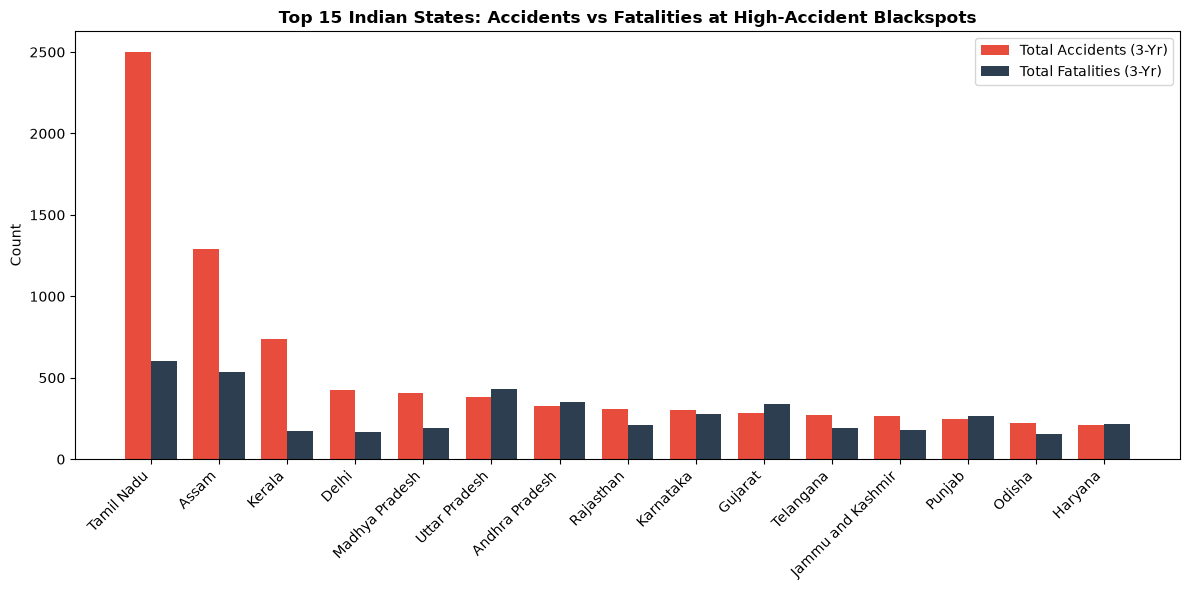

✅ Chart saved: D:\FYP\SafeRoute-AI\reports\08_india_state_accidents_fatalities.png


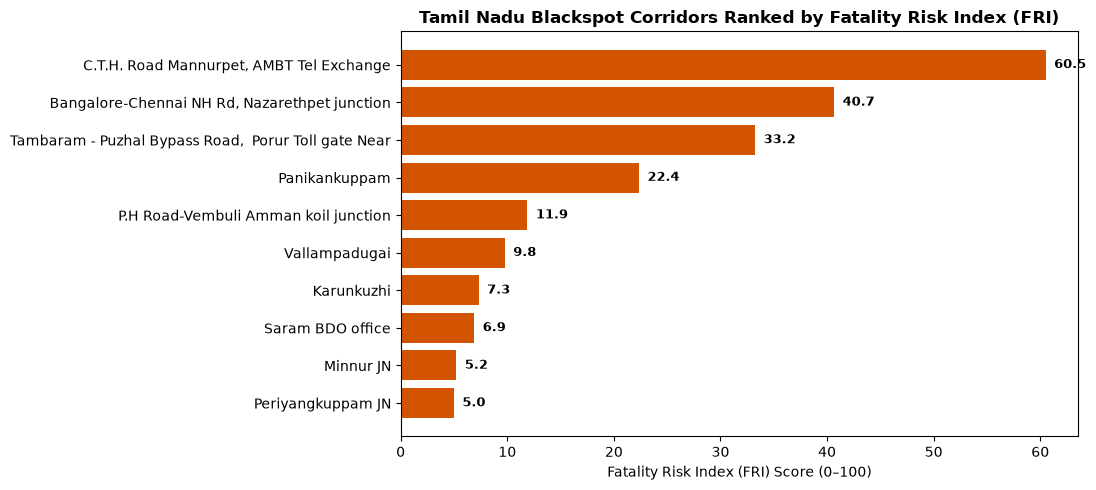

✅ Chart saved: D:\FYP\SafeRoute-AI\reports\09_tamilnadu_top_corridors_fri.png


In [5]:
# Save cleaned Indian blackspot data
clean_india_path = r"D:\FYP\SafeRoute-AI\data\india_blackspots_clean.csv"
df_india.to_csv(clean_india_path, index=False)
print(f"✅ Cleaned Indian data saved: {clean_india_path}")

# Chart 1: State-wise Accidents vs Fatalities (Top 15 States)
top_states = df_india.groupby('State').agg(
    Accidents=('Numbers of Accidents - Total of all three years', 'sum'),
    Fatalities=('Numbers of Fatalities - Total of all three years', 'sum')
).sort_values(by='Accidents', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top_states))
width = 0.38

ax.bar(x - width/2, top_states['Accidents'], width, label='Total Accidents (3-Yr)', color='#e74c3c')
ax.bar(x + width/2, top_states['Fatalities'], width, label='Total Fatalities (3-Yr)', color='#2c3e50')

ax.set_title('Top 15 Indian States: Accidents vs Fatalities at High-Accident Blackspots', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_states.index, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
chart_path1 = os.path.join(REPORTS_DIR, "08_india_state_accidents_fatalities.png")
plt.savefig(chart_path1, dpi=150)
plt.show()
print(f"✅ Chart saved: {chart_path1}")

# Chart 2: Top Tamil Nadu Blackspot Corridors by Fatality Risk Index (FRI)
fig, ax = plt.subplots(figsize=(11, 5))
tn_plot = tn_blackspots.sort_values(by='Fatality_Risk_Index', ascending=True)

bars = ax.barh(tn_plot['Name of Location Place'], tn_plot['Fatality_Risk_Index'], color='#d35400')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.8, bar.get_y() + bar.get_height()/2, f'{w:.1f}', va='center', fontweight='bold', fontsize=9)

ax.set_title('Tamil Nadu Blackspot Corridors Ranked by Fatality Risk Index (FRI)', fontsize=12, fontweight='bold')
ax.set_xlabel('Fatality Risk Index (FRI) Score (0–100)')
plt.tight_layout()
chart_path2 = os.path.join(REPORTS_DIR, "09_tamilnadu_top_corridors_fri.png")
plt.savefig(chart_path2, dpi=150)
plt.show()
print(f"✅ Chart saved: {chart_path2}")